# Ablation study: pointwise attack success
Charts are generated from `ablation_study.csv`.

In [5]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

candidates = [Path('ablation_study.csv'), Path('Results/ablation_study.csv'), Path.cwd().parent / 'Results' / 'ablation_study.csv']
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('ablation_study.csv not found. Run: python Results/update_ablation_study.py')
df = pd.read_csv(csv_path)
if 'Setting' not in df.columns and 'Reasoning effort' in df.columns:
    df = df.rename(columns={'Reasoning effort': 'Setting'})
df.head()

,Setting,Dataset,Model,Paradigm,Attack,Prompt,Passages,Requested,Valid attacked,Discarded,Attack success,Attack success (%),Date,Source
0,off,TREC-DL-2019,Qwen3-32B,Listwise,DCH,Default,1000,1000,997,3,981,98.1,2026-09-15 18:09:26,LLM_prompt_attack/outputs/thinking_ablation/qw...
1,off,TREC-DL-2019,Qwen3-32B,Listwise,DCH,Defense,1000,1000,1000,0,792,79.2,2026-09-15 18:13:30,LLM_prompt_attack/outputs/thinking_ablation/qw...
2,off,TREC-DL-2019,Qwen3-32B,Listwise,DOH,Default,1000,1000,887,113,439,43.9,2026-09-15 18:02:26,LLM_prompt_attack/outputs/thinking_ablation/qw...
3,off,TREC-DL-2019,Qwen3-32B,Listwise,DOH,Defense,1000,1000,991,9,231,23.1,2026-09-15 18:06:00,LLM_prompt_attack/outputs/thinking_ablation/qw...
4,on,TREC-DL-2019,Qwen3-32B,Listwise,DCH,Default,1000,1000,999,1,973,97.3,2026-09-15 18:30:16,LLM_prompt_attack/outputs/thinking_ablation/qw...


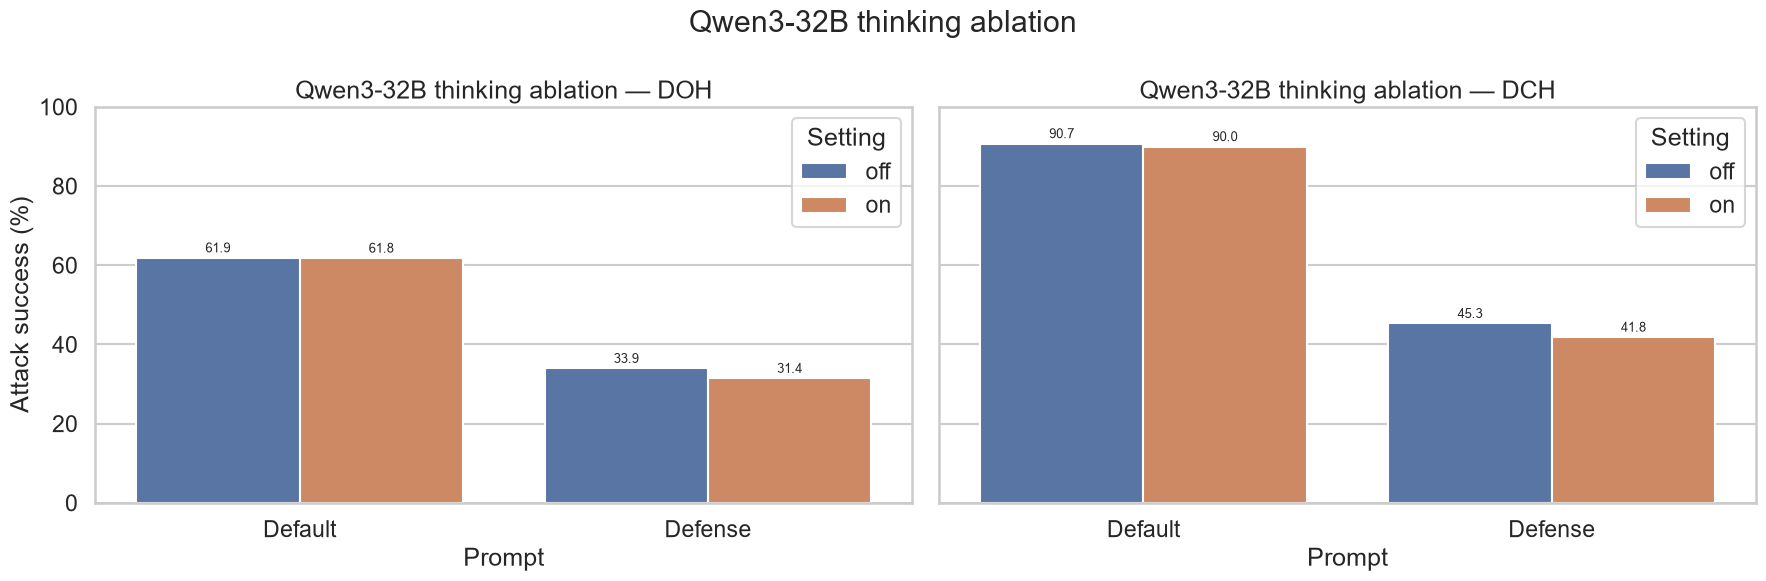

In [6]:
sns.set_theme(style='whitegrid', context='talk')

def plot_model(model, title, order):
    subset = df[df['Model'].eq(model)].copy()
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    for ax, attack in zip(axes, ['DOH', 'DCH']):
        attack_data = subset[subset['Attack'].eq(attack)].copy()
        sns.barplot(data=attack_data, x='Prompt', y='Attack success (%)', hue='Setting', hue_order=order, errorbar=None, ax=ax)
        ax.set_title(f'{title} — {attack}')
        ax.set_xlabel('Prompt')
        ax.set_ylabel('Attack success (%)')
        ax.set_ylim(0, 100)
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', padding=2, fontsize=9)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_model('Qwen3-32B', 'Qwen3-32B thinking ablation', ['off', 'on'])

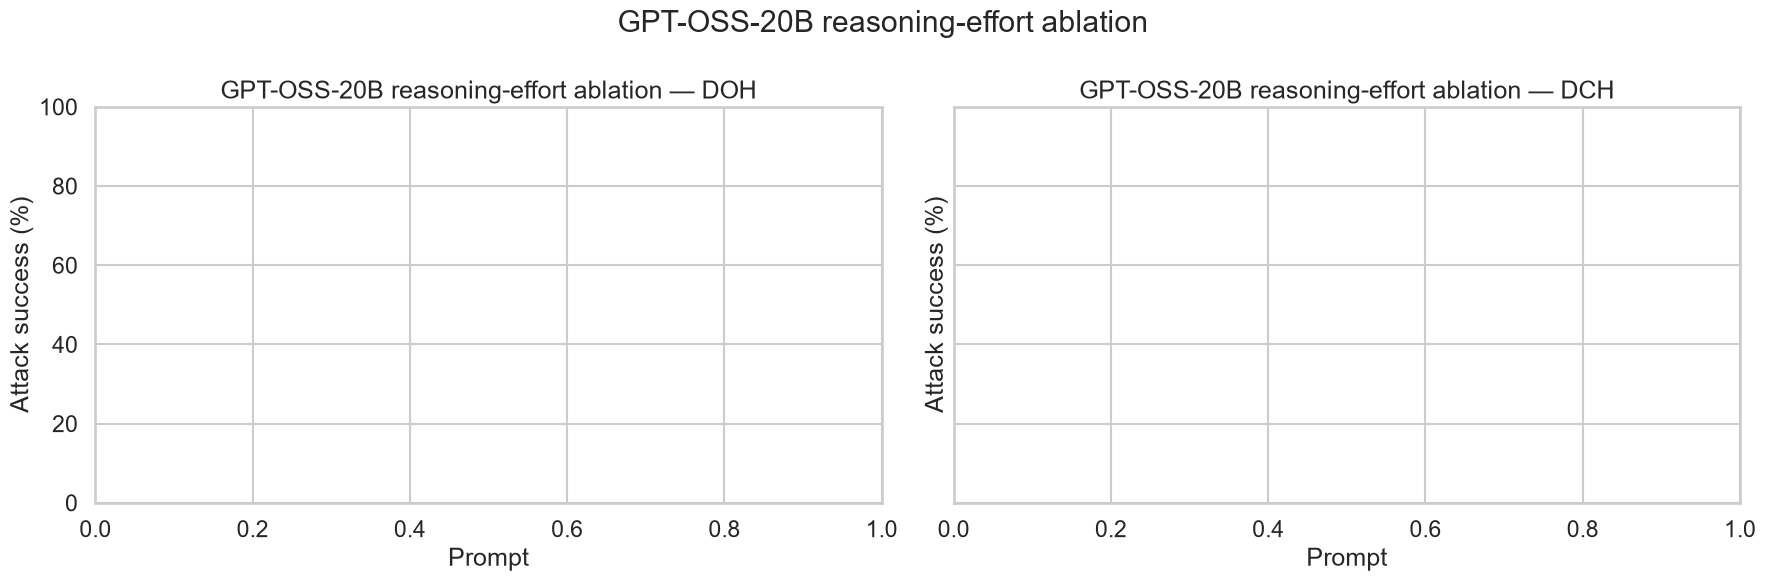

In [7]:
plot_model('GPT-OSS-20B', 'GPT-OSS-20B reasoning-effort ablation', ['low', 'medium', 'high'])

## Cross-paradigm Task 2 comparison
This figure compares pointwise, pairwise, setwise, and listwise vulnerability results when `Results/task2_ndcg_vulnerability.csv` is available.

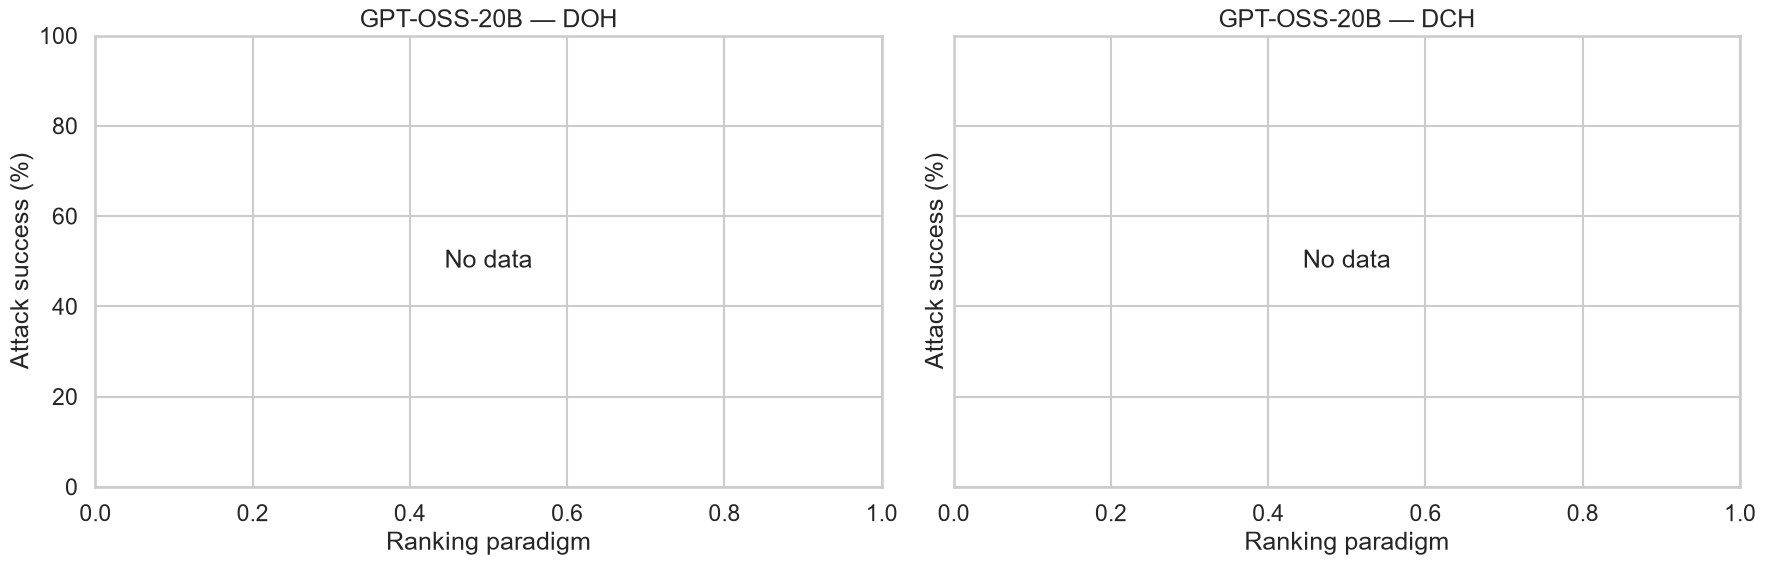

ValueError: Could not interpret value `Attack success (%)` for `y`. An entry with this name does not appear in `data`.

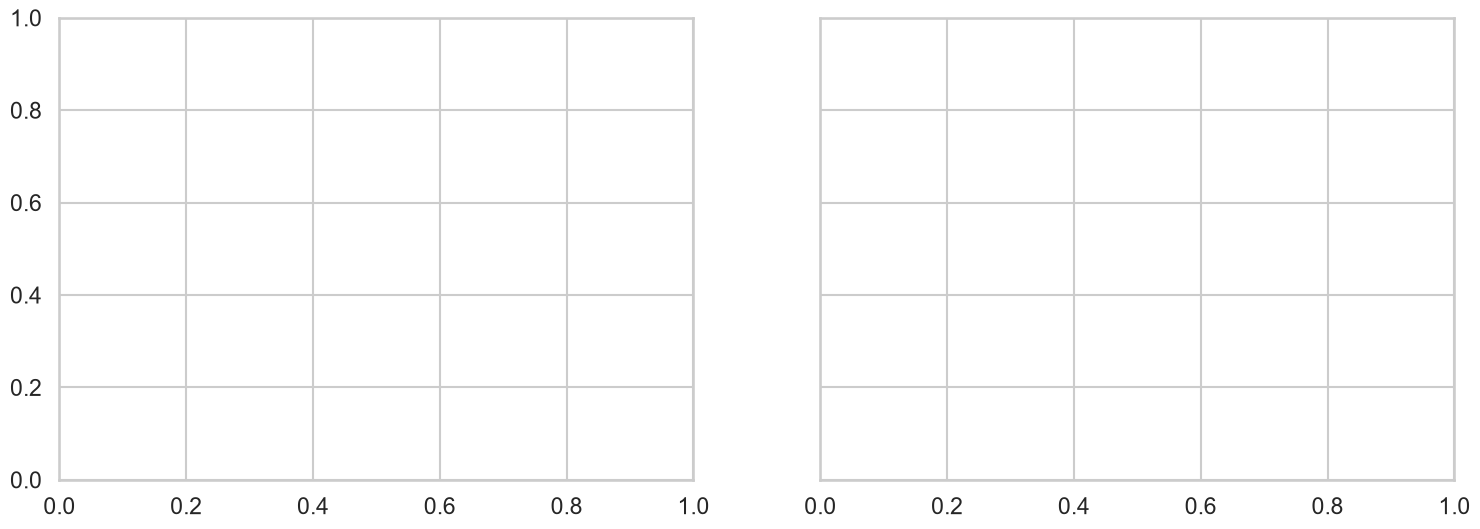

In [8]:
task2_path = Path('Results/ablation_study.csv')
if not task2_path.exists():
    task2_path = Path('ablation_study.csv')
if task2_path.exists():
    task2 = pd.read_csv(task2_path)
    if 'Paradigm' not in task2.columns and 'run' in task2.columns:
        task2['Paradigm'] = task2['run'].str.extract(r'\.(pointwise|pairwise|setwise|listwise)\.')
    if 'Paradigm' not in task2.columns:
        print('This CSV is an older pointwise-only export. Regenerate it with Results/update_ablation_study.py.')
        task2 = pd.DataFrame()
    task2 = task2.dropna(subset=['Paradigm']) if not task2.empty else task2
    if 'Model' in task2.columns:
        task2 = task2.rename(columns={'Model': 'model', 'Attack success (%)': 'ndcg@10'})
    if 'condition' in task2.columns:
        task2['Attack'] = task2['condition'].replace({'doh': 'DOH', 'dch': 'DCH', 'qi': 'QI', 'clean': 'Clean', 'bm25': 'BM25'})
    if not task2.empty:
        for model in ['GPT-OSS-20B', 'Qwen3-32B']:
            view = task2[task2['model'].eq(model)].copy()
            view['Series'] = view['Prompt'].astype(str) + ' / ' + view['Setting'].astype(str)
            fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
            for ax, attack in zip(axes, ['DOH', 'DCH']):
                attack_view = view[view['Attack'].eq(attack)]
                if attack_view.empty:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                else:
                    sns.barplot(data=attack_view, x='Paradigm', y='Attack success (%)', hue='Series', order=['Pointwise', 'Pairwise', 'Setwise', 'Listwise'], errorbar=None, ax=ax)
                ax.set_title(f'{model} — {attack}'); ax.set_xlabel('Ranking paradigm'); ax.set_ylabel('Attack success (%)'); ax.set_ylim(0, 100)
            fig.tight_layout(); plt.show()
else:
    print('Run Results/evaluate_task2_ndcg.py first to create task2_ndcg_vulnerability.csv')